In [2]:
# 1- Initial Imports
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import transforms

In [1]:
# 2- Dataset Initialization Phase

import os
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
from torchvision import transforms
import torch
import torchvision.transforms.functional as TF
import random
from natsort import natsorted
import platform

class SegmentationDataset(Dataset):
    def __init__(self, dataset_type, color_map=None, augment=False): #Default mode is no color map and augmentation, unless prompted
        base_dir = r"C:/My Files/Semester4TUM/Developed Dataset/Prepared Dataset for Thesis - fixed class imbalance"

        if dataset_type not in ["train", "val", "test"]:
            raise ValueError("dataset_type must be 'train', 'val', or 'test'")

        self.image_dir = os.path.join(base_dir, dataset_type, "image")
        self.mask_dir = os.path.join(base_dir, dataset_type, "mask")

        self.image_filenames = natsorted(os.listdir(self.image_dir))
        self.mask_filenames = natsorted(os.listdir(self.mask_dir)) #These two lines ensure the images and corresponding masks are loaded together

        self.color_map = color_map
        self.augment = augment

        self.transform_image = transforms.Compose([   #Imagenet dataset stats
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_filenames[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_filenames[idx]) #These two lines ensure the images and corresponding masks are loaded together

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("RGB")

        if self.augment:
            if random.random() > 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)
            if random.random() > 0.5:
                image = TF.vflip(image)
                mask = TF.vflip(mask)

        image = self.transform_image(image)

        mask_np = np.array(mask)
        mask_indices = np.zeros(mask_np.shape[:2], dtype=np.int64)

        found_colors = set()

        for rgb, class_idx in self.color_map.items():
            match = np.all(mask_np == rgb, axis=-1)
            mask_indices[match] = class_idx
            found_colors.add(rgb)

        unique_colors_in_mask = np.unique(mask_np.reshape(-1, 3), axis=0)
        for color in map(tuple, unique_colors_in_mask):
            if color not in self.color_map:
                print(f" Warning: Unknown color in mask: {color}")

        mask_tensor = torch.tensor(mask_indices, dtype=torch.long)

        return image, mask_tensor


#  Color map: RGB → class index
color_map = {
    (0, 0, 0): 0,        # Formal
    (0, 0, 255): 1,      # Other Background
    (255, 0, 0): 2       # Informal
}

#  Safe entry point for Windows because of an issue with data loaders
if __name__ == "__main__":
    dataset = SegmentationDataset(dataset_type="train", color_map=color_map, augment=True)

    #  Choose num_workers based on OS
    num_workers = 0 if platform.system() == "Windows" else 4 # the problem area that prompted the creation of the safe entry point

    train_loader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=num_workers)

    image, mask = next(iter(train_loader))
    print("Image batch shape:", image.shape)  # [B, 3, H, W]
    print("Mask batch shape:", mask.shape)    # [B, H, W]
    print("Mask classes in batch:", torch.unique(mask))


Image batch shape: torch.Size([4, 3, 189, 229])
Mask batch shape: torch.Size([4, 189, 229])
Mask classes in batch: tensor([0, 1, 2])


In [3]:
# 3- Preparing the datasets and dataloaders
from torch.utils.data import DataLoader
import platform


if __name__ == "__main__":
        # Initialize datasets
    train_dataset = SegmentationDataset(dataset_type="train", color_map=color_map, augment=True)
    val_dataset = SegmentationDataset(dataset_type="val", color_map=color_map, augment=False)
    test_dataset = SegmentationDataset(dataset_type="test", color_map=color_map, augment=False)
    num_workers = 0 if platform.system() == "Windows" else 4

    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=num_workers)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=num_workers)

    # Now safe to use train_loader, val_loader, test_loader


In [4]:
# 4- DeepLabV3 segmentation model with a ResNet18 backbone.

import torch.nn as nn
from torchvision.models.segmentation import DeepLabV3
from torchvision.models.segmentation.deeplabv3 import DeepLabHead
from torchvision.models import resnet18

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #Device Setup
num_classes = 3  # Define your number of classes here

class ResNet18BackboneWrapper(nn.Module):
    def __init__(self):
        super().__init__()
        base_model = resnet18(weights="IMAGENET1K_V1")
        self.backbone = nn.Sequential(*list(base_model.children())[:-2])  # Remove avgpool and fc

    def forward(self, x):
        x = self.backbone(x)
        return {"out": x}  # 👈 Wrap in dict

# Now define the model
backbone = ResNet18BackboneWrapper()
model = DeepLabV3(backbone=backbone, classifier=DeepLabHead(512, num_classes))

# Move model to selected device
model = model.to(device)

# Print model summary
print(model)


DeepLabV3(
  (backbone): ResNet18BackboneWrapper(
    (backbone): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): Batch

In [5]:
# 5- Setup of loss function, optimizer, and learning rate scheduler
from torch import nn, optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Initial learning rate

# Add StepLR scheduler - decrease LR by gamma every step_size epochs
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)  

In [6]:
# 6- the full training loop, validation, metrics, scheduler, and early stopping.
import torch
import torch.nn.functional as F

def train_model(train_loader, val_loader, model, criterion, optimizer, scheduler=None, num_epochs=1, patience=5):
    # Set device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    best_val_loss = float("inf")
    epochs_no_improve = 0

    for epoch in range(num_epochs):  #Iterating all over epochs for training
        model.train()                #Setting the model on training mode
        train_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:     #Iterating over training batches
            # Move data to device
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()               #Forward pass optimization
            outputs = model(images)["out"]
            outputs = F.interpolate(outputs, size=labels.shape[1:], mode='bilinear', align_corners=False)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

            preds = torch.argmax(outputs, dim=1) #Training accuracy
            correct_train += (preds == labels).sum().item()
            total_train += labels.numel()

        train_accuracy = 100 * correct_train / total_train   #Averaging training metrics
        avg_train_loss = train_loss / len(train_loader)

        model.eval()                              #Putting model onto evaluation mode
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for images, labels in val_loader:
                # Move data to device
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)["out"]
                outputs = F.interpolate(outputs, size=labels.shape[1:], mode='bilinear', align_corners=False)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                correct_val += (preds == labels).sum().item()
                total_val += labels.numel()

        val_accuracy = 100 * correct_val / total_val
        avg_val_loss = val_loss / len(val_loader)

        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.2f}%, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%")

        if scheduler is not None:   #Updating the learning rate according to the scheduler
            scheduler.step()

        if avg_val_loss < best_val_loss:       #setting up early stopping - 
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    return model


In [7]:
# 7- testing, evaluation, and saving predictions

import os
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, f1_score

test_mask_dir = r"C:/My Files/Semester4TUM/Developed Dataset/Prepared Dataset for Thesis - fixed class imbalance/test/mask"
output_dir = r"C:/My Files/Semester4TUM/Developed Dataset/Prepared Dataset for Thesis - fixed class imbalance/test/predictions"  # changed!

os.makedirs(output_dir, exist_ok=True)

test_mask_filenames = [f for f in os.listdir(test_mask_dir) if f.endswith('.png')]

class_colors = {  #Mapping class indices to RGB colors for visualization
    0: (0, 0, 0),      # Informal Settlements
    1: (0, 0, 255),    # Built-Up
    2: (255, 0, 0),    # Informal? Confirm class labels and colors!
}

def apply_color_map(mask, color_map):  #Converting a 2D mask (class indecies) to a 3 channel RGB mask
    color_mask = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
    for class_idx, color in color_map.items():
        color_mask[mask == class_idx] = color
    return color_mask

def test_model(test_loader, model, criterion, test_mask_filenames):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()  #Puts on evaluation mode

    running_loss = 0.0    #initialize tracking variables
    running_accuracy = 0.0
    all_preds = []
    all_labels = []

    file_counter = 0

    with torch.no_grad():   #Loop over batches
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)["out"]    #model inference and loss
            outputs = F.interpolate(outputs, size=labels.shape[1:], mode='bilinear', align_corners=False)

            loss = criterion(outputs, labels)
            running_loss += loss.item()

            _, predicted = torch.max(outputs, dim=1)   #get the predicted masks

            for i in range(predicted.shape[0]):        #save the predicted masks as images
                if file_counter >= len(test_mask_filenames):
                    print("Warning: file_counter exceeded test_mask_filenames length.")
                    break

                pred_mask = predicted[i].cpu().numpy()
                colored_pred_mask = apply_color_map(pred_mask, class_colors)

                filename = os.path.basename(test_mask_filenames[file_counter])
                save_path = os.path.join(output_dir, filename)
                plt.imsave(save_path, colored_pred_mask)

                file_counter += 1

            correct = (predicted == labels).sum().item()   #computing batch accuracy
            total = labels.numel()
            accuracy = correct / total
            running_accuracy += accuracy

            all_preds.append(predicted.cpu().numpy())    #collecting all predictions and metrics
            all_labels.append(labels.cpu().numpy())

    avg_loss = running_loss / len(test_loader)          #average loss metrics
    avg_accuracy = running_accuracy / len(test_loader)

    print(f"Test Loss: {avg_loss:.4f}, Test Accuracy: {avg_accuracy:.4f}")

    all_preds = np.concatenate([x.flatten() for x in all_preds])     #flatten arrays for Sklearn matrics
    all_labels = np.concatenate([x.flatten() for x in all_labels])

    conf_matrix = confusion_matrix(all_labels, all_preds)    #compute evaluation metrics
    f1 = f1_score(all_labels, all_preds, average=None)

    print("Confusion Matrix:\n", conf_matrix)
    print("F1 Scores per class:", f1)

    producer_accuracy = np.diag(conf_matrix) / np.sum(conf_matrix, axis=1)
    user_accuracy = np.diag(conf_matrix) / np.sum(conf_matrix, axis=0)

    print("Producer Accuracy per class:", producer_accuracy)
    print("User Accuracy per class:", user_accuracy)

    return avg_loss, avg_accuracy, conf_matrix, f1, producer_accuracy, user_accuracy

print("Model device:", next(model.parameters()).device)  #quick sanity check


In [9]:
#8- Train and Test the entire model

# Unfreeze all layers for fine-tuning
for param in model.parameters():
    param.requires_grad = True
# Training the Model
trained_model = train_model(train_loader,val_loader, model, criterion, optimizer, num_epochs=5,)
# Testing the Model
test_model(test_loader, trained_model, criterion, test_mask_filenames)

Epoch [1/5], Train Loss: 0.6951, Train Acc: 71.34%, Val Loss: 0.5352, Val Acc: 79.82%
Epoch [2/5], Train Loss: 0.5300, Train Acc: 79.19%, Val Loss: 0.5810, Val Acc: 75.66%
Epoch [3/5], Train Loss: 0.5415, Train Acc: 78.26%, Val Loss: 0.5584, Val Acc: 77.93%
Epoch [4/5], Train Loss: 0.5060, Train Acc: 80.60%, Val Loss: 0.4810, Val Acc: 81.78%
Epoch [5/5], Train Loss: 0.4814, Train Acc: 80.62%, Val Loss: 0.4725, Val Acc: 82.39%
Test Loss: 0.5687, Test Accuracy: 0.7859
Confusion Matrix:
 [[ 975149  199572   94615]
 [ 296173 1390416  373965]
 [  93251   68752 1701827]]
F1 Scores per class: [0.74045762 0.74767738 0.84369213]
Producer Accuracy per class: [0.76823552 0.67477775 0.91308059]
User Accuracy per class: [0.71461842 0.83823625 0.78410501]


(0.5687204301357269,
 0.7859417238511124,
 array([[ 975149,  199572,   94615],
        [ 296173, 1390416,  373965],
        [  93251,   68752, 1701827]], dtype=int64),
 array([0.74045762, 0.74767738, 0.84369213]),
 array([0.76823552, 0.67477775, 0.91308059]),
 array([0.71461842, 0.83823625, 0.78410501]))

In [10]:
# 9- Head Only Fine-Tuning

for param in trained_model.backbone.parameters():
    param.requires_grad = False  # Freeze ResNet-18 layers (Backbone)

for param in trained_model.classifier.parameters():
    param.requires_grad = True   # Train only the segmentation head

# use a new optimizer
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, trained_model.parameters()), lr=1e-4)

# continue training
fine_tuned_model = train_model(train_loader, val_loader, trained_model, criterion, optimizer, num_epochs=1)
# conduct testing
test_model(test_loader, fine_tuned_model, criterion, test_mask_filenames)

Epoch [1/1], Train Loss: 0.4505, Train Acc: 82.14%, Val Loss: 0.4597, Val Acc: 82.50%
Test Loss: 0.5661, Test Accuracy: 0.7911
Confusion Matrix:
 [[ 981364  193063   94909]
 [ 284040 1405615  370899]
 [  95299   60725 1707806]]
F1 Scores per class: [0.74627334 0.75571572 0.84598375]
Producer Accuracy per class: [0.77313178 0.68215393 0.9162885 ]
User Accuracy per class: [0.72121837 0.84706066 0.78569884]


(0.5660610795021057,
 0.7911179270349576,
 array([[ 981364,  193063,   94909],
        [ 284040, 1405615,  370899],
        [  95299,   60725, 1707806]], dtype=int64),
 array([0.74627334, 0.75571572, 0.84598375]),
 array([0.77313178, 0.68215393, 0.9162885 ]),
 array([0.72121837, 0.84706066, 0.78569884]))

In [11]:
#10- Saving the model in a custom directory

import os

# Define your custom directory path
custom_dir = r"C:\My Files\Semester4TUM\saved_model_weights"

# Create the directory if it doesn't exist
os.makedirs(custom_dir, exist_ok=True)

# Define the full file path including filename
save_path = os.path.join(custom_dir, "fine_tuned_deeplabv3_resnet18.pth")

# Save the model weights
torch.save(fine_tuned_model.state_dict(), save_path)


In [12]:
#11- Loading The Model Back

#Recreating the model's architecture
backbone = ResNet18BackboneWrapper()
model = DeepLabV3(backbone=backbone, classifier=DeepLabHead(512, num_classes))

#loading the saved weights
model.load_state_dict(torch.load(save_path))
#move the model to the appropriate device
model = model.to(device)

model.eval()  # set to evaluation mode


C:\Users\esmat\AppData\Local\Temp\ipykernel_21448\3553459731.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path))


DeepLabV3(
  (backbone): ResNet18BackboneWrapper(
    (backbone): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): Batch

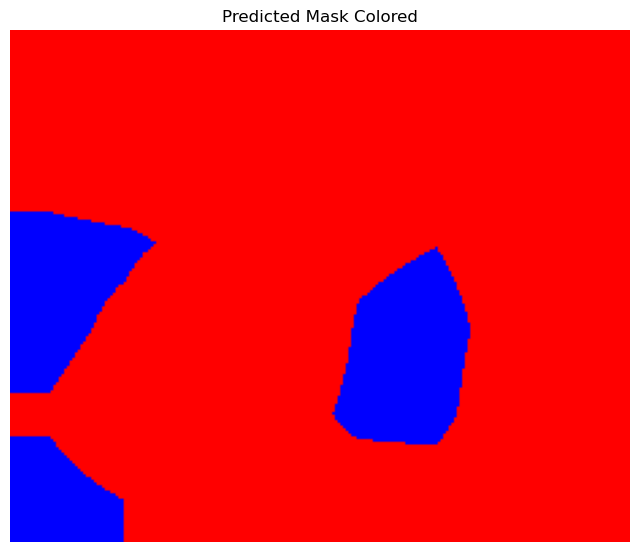

In [23]:
import torch
from PIL import Image
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Path to the image
img_path = r"C:\Users\esmat\Desktop\New folder\patch_791.tif"

# Transform (same as training)
transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

# Load image
img = Image.open(img_path).convert("RGB")
input_tensor = transform(img).unsqueeze(0).to(device)  # Add batch dimension

# Run model
model.eval()
with torch.no_grad():
    outputs = model(input_tensor)['out']  # shape: (1, num_classes, H, W)
    predicted_mask = torch.argmax(outputs, dim=1).squeeze(0).cpu().numpy()  # shape: (H, W)

# Define colormap (index = class ID)
colormap = np.array([
    [0, 0, 0],       # Formal
    [0, 0, 255],     # Other Background
    [255, 0, 0],     # Informal
], dtype=np.uint8)

# Map predicted classes to colors
color_mask = colormap[predicted_mask]

# Display colored mask
plt.figure(figsize=(8, 8))
plt.imshow(color_mask)
plt.title("Predicted Mask Colored")
plt.axis('off')
plt.show()
